# Motor Simulation

## Model

In [111]:
import numpy as np
import pandas as pd


class MotorSimulation:

    def __init__(self, dt=0.05, duration_days=11):

        self.dt = dt
        self.T = int(duration_days * 24 * 3600 / dt)

        # =========================
        # MOTOR
        # =========================

        self.J = 8.5
        self.B0 = 6.0
        self.kt = 4.2

        self.omega_ref_base = 157
        self.omega_ref = 157

        self.current_limit = 400
        self.current_ramp = 5

        # =========================
        # CARGA MECÂNICA
        # =========================

        self.tau0 = 850
        self.load_amp = 200
        self.load_period = int(1200 / dt)

        # =========================
        # SENSOR NOISE
        # =========================

        self.sigma_speed = 0.2
        self.sigma_current = 0.5
        self.sigma_vibration = 0.2

        # =========================
        # THERMAL MODEL
        # =========================

        self.thermal_mass = 8000
        self.cooling = 0.15
        self.ambient_temp = 25

        # =========================
        # STRUCTURAL DYNAMICS
        # =========================

        self.struct_freq = 8
        self.struct_damping = 0.12

        self.res_state1 = 0
        self.res_state2 = 0

        # Impact control
        self.impact_timer = 0
        self.current_impact_amp = 0

        # =========================
        # SCENARIOS
        # =========================

        self.scenarios = [

            "healthy",
            "load_change",
            "resonance",
            "lubrication_starvation",
            "bearing_wear",
            "imbalance",
            "misalignment",
            "looseness",
            "outer_race_defect",
            "inner_race_defect",
            "load_change_bearing_wear"
        ]

        block = int(self.T / len(self.scenarios))

        self.scenario_intervals = {
            s: (i * block, (i + 1) * block)
            for i, s in enumerate(self.scenarios)
        }

        self.auto_tune_pi()

    # ==================================
    # PI AUTOTUNING
    # ==================================

    def auto_tune_pi(self):

        wc = self.B0 / self.J

        self.Kp = (self.J * wc) / self.kt
        self.Ki = (self.B0 * wc) / self.kt

    # ==================================
    # STRUCTURAL FILTER
    # ==================================

    def structural_filter(self, x):
    
        w = 2*np.pi*self.struct_freq
        z = self.struct_damping
        dt = self.dt
    
        # coeficientes discretos estáveis
        a = np.exp(-z*w*dt)
        b = np.sin(w*dt)
    
        new_state = (
            a * (self.res_state1 * np.cos(w*dt) +
                 self.res_state2 * b / w)
            + 0.1 * x
        )
    
        self.res_state2 = (
            -self.res_state1 * w * b +
            self.res_state2 * np.cos(w*dt)
        ) * a
    
        self.res_state1 = new_state
    
        return self.res_state1
    
    # ==================================
    # IMPACT MODEL
    # ==================================

    def ring_down(self, amplitude, freq, t):

        decay = np.exp(-15.0 * t)

        return amplitude * decay * np.sin(2 * np.pi * freq * t)

    # ==================================
    # ACTIVE SCENARIO
    # ==================================

    def get_scenario(self, k):

        for name, (start, end) in self.scenario_intervals.items():

            if start <= k < end:
                return name

        return "healthy"

    # ==================================
    # SIMULATION
    # ==================================

    def simulate(self):

        t = np.arange(self.T)

        omega = np.zeros(self.T)
        current = np.zeros(self.T)
        vibration = np.zeros(self.T)
        tau_load = np.zeros(self.T)
        temperature = np.zeros(self.T)

        scenario_label = []

        temperature[0] = self.ambient_temp

        integral_error = 0

        for k in range(self.T - 1):

            scenario = self.get_scenario(k)

            scenario_label.append(scenario)

            # =========================
            # LOAD
            # =========================

            base_tau = self.tau0 + self.load_amp * np.sin(2 * np.pi * k / self.load_period)

            if scenario in ["load_change", "load_change_bearing_wear"]:
                base_tau *= 1.35

            tau_load[k] = base_tau

            # =========================
            # SPEED REFERENCE VARIATION
            # =========================

            self.omega_ref = self.omega_ref_base * (
                1 + 0.01 * np.sin(2 * np.pi * k / 20000)
            )

            # =========================
            # PI CONTROL
            # =========================

            error = self.omega_ref - omega[k]

            candidate_integral = integral_error + error * self.dt

            current_cmd = np.clip(
                self.Kp * error + self.Ki * candidate_integral,
                -self.current_limit,
                self.current_limit
            )

            if abs(current_cmd) < self.current_limit:
                integral_error = candidate_integral

            prev_current = current[k - 1] if k > 0 else 0

            delta = current_cmd - prev_current

            max_delta = self.current_ramp * self.dt

            current[k] = prev_current + np.sign(delta) * min(abs(delta), max_delta)

            # =========================
            # ROTATIONAL DYNAMICS
            # =========================

            torque_motor = self.kt * current[k]

            omega[k + 1] = omega[k] + (self.dt / self.J) * (
                torque_motor
                - tau_load[k]
                - self.B0 * omega[k]
            )

            # =========================
            # VIBRATION MODEL
            # =========================

            rot_freq = max(omega[k] / (2 * np.pi), 0.1)

            structural_baseline = (
                0.002 * tau_load[k]
                + 0.0015 * omega[k]
            )

            vibration_fault = 0

            # small stochastic variation of bearing frequencies
            bpfo = (4.5 + np.random.normal(0, 0.1)) * rot_freq
            bpfi = (5.5 + np.random.normal(0, 0.1)) * rot_freq

            # =========================
            # FAULT INJECTION
            # =========================

            if scenario in ["bearing_wear", "load_change_bearing_wear"]:
                vibration_fault += 0.8 * np.sin(2 * np.pi * bpfo * k * self.dt)

            if scenario == "imbalance":
                vibration_fault += 0.9 * np.sin(2 * np.pi * rot_freq * k * self.dt)

            if scenario == "misalignment":
                vibration_fault += 0.7 * np.sin(2 * np.pi * 2 * rot_freq * k * self.dt)

            if scenario == "lubrication_starvation":
                vibration_fault += np.random.normal(0, 0.6)

            if scenario == "resonance":
                vibration_fault += 1.5 * np.sin(2 * np.pi * self.struct_freq * k * self.dt)

            # =========================
            # IMPACT EVENTS
            # =========================

            severity = abs(vibration_fault)

            impact_prob = min(0.01 + 0.04 * severity, 0.08)

            if scenario in ["looseness", "inner_race_defect", "outer_race_defect"]:

                if np.random.rand() < impact_prob and self.impact_timer <= 0:

                    self.impact_timer = 30
                    self.current_impact_amp = np.random.lognormal(1.0, 0.4)

                if self.impact_timer > 0:

                    t_impact = (30 - self.impact_timer) * self.dt

                    mod = (
                        0.5 * (1 + np.cos(2 * np.pi * rot_freq * k * self.dt))
                        if scenario == "inner_race_defect"
                        else 1.0
                    )

                    vibration_fault += mod * self.ring_down(
                        self.current_impact_amp,
                        self.struct_freq,
                        t_impact
                    )

                    self.impact_timer -= 1

            # =========================
            # LOAD MODULATION
            # =========================

            load_mod = 1 + 0.0008 * tau_load[k]

            vibration_fault *= load_mod

            # =========================
            # FINAL SIGNAL
            # =========================

            noise = np.random.normal(0, self.sigma_vibration)

            vibration_total = structural_baseline + vibration_fault + noise

            vibration[k] = self.structural_filter(vibration_total)

            # =========================
            # THERMAL MODEL
            # =========================

            ambient = self.ambient_temp

            if scenario == "ambient_drift":
                ambient += 12 * np.sin(2 * np.pi * k / (self.T / 11))

            loss_mod = 1.4 if scenario == "lubrication_starvation" else 1.0

            copper_loss = 0.00015 * (current[k]**2) * loss_mod

            temperature[k + 1] = temperature[k] + (
                self.dt / self.thermal_mass
            ) * (
                copper_loss
                - self.cooling * (temperature[k] - ambient)
            )

        scenario_label.append(scenario_label[-1])

        return {
            "time": t,
            "omega": omega + np.random.normal(0, self.sigma_speed, self.T),
            "current": current + np.random.normal(0, self.sigma_current, self.T),
            "vibration": vibration,
            "temperature": temperature,
            "load": tau_load,
            "scenario": scenario_label
        }

    # ==================================
    # DATASET BUILD
    # ==================================

    def build_dataset(self, data):

        df = pd.DataFrame(data)

        df["day"] = (df["time"] * self.dt) / (3600 * 24)

        df["vibration_rms"] = df["vibration"].rolling(200).std()
        df["vibration_kurtosis"] = df["vibration"].rolling(200).kurt()

        df["current_rms"] = df["current"].rolling(200).std()

        df["temp_gradient"] = df["temperature"].diff()

        return df.dropna()

## Simulation

In [112]:
# Instanciando simulação (teste rápido)
sim = MotorSimulation(duration_days=0.3)

# Executando dinâmica
dados_brutos = sim.simulate()

# Construindo dataset de features
df = sim.build_dataset(dados_brutos)

print(f"Total de amostras geradas: {len(df)}")

print("\nPrimeiras linhas do dataset:")
print(df[['omega','current','vibration','temperature','scenario']].head())

print("\nFeatures calculadas:")
print(df[['vibration_rms','vibration_kurtosis','current_rms','temp_gradient']].head())

print("\nDistribuição dos cenários:")
print(df['scenario'].value_counts())

Total de amostras geradas: 518200

Primeiras linhas do dataset:
          omega    current  vibration  temperature scenario
199 -112.918006  50.023334   0.106038    25.000155  healthy
200 -113.055948  50.150359   0.098494    25.000157  healthy
201 -112.707983  50.561542   0.051480    25.000160  healthy
202 -112.070294  50.319198   0.105651    25.000162  healthy
203 -112.441006  51.225727   0.102558    25.000165  healthy

Features calculadas:
     vibration_rms  vibration_kurtosis  current_rms  temp_gradient
199       0.023386            0.036102    14.487849       0.000002
200       0.022913           -0.062281    14.485475       0.000002
201       0.023065           -0.098654    14.491119       0.000002
202       0.023059           -0.101243    14.482214       0.000002
203       0.023058           -0.100447    14.482623       0.000002

Distribuição dos cenários:
scenario
load_change                 47127
resonance                   47127
lubrication_starvation      47127
bearing_wear 

## Simulation Summary


Resumo médio por cenário:


,vibration_rms,vibration_kurtosis
scenario,,
resonance,0.410874,-1.476531
load_change_bearing_wear,0.136928,-0.651522
lubrication_starvation,0.128301,-0.002667
imbalance,0.122808,-0.707504
bearing_wear,0.120839,-0.668942
misalignment,0.102082,-0.476740
looseness,0.037019,9.218307
outer_race_defect,0.035374,7.988127
inner_race_defect,0.028724,3.359863


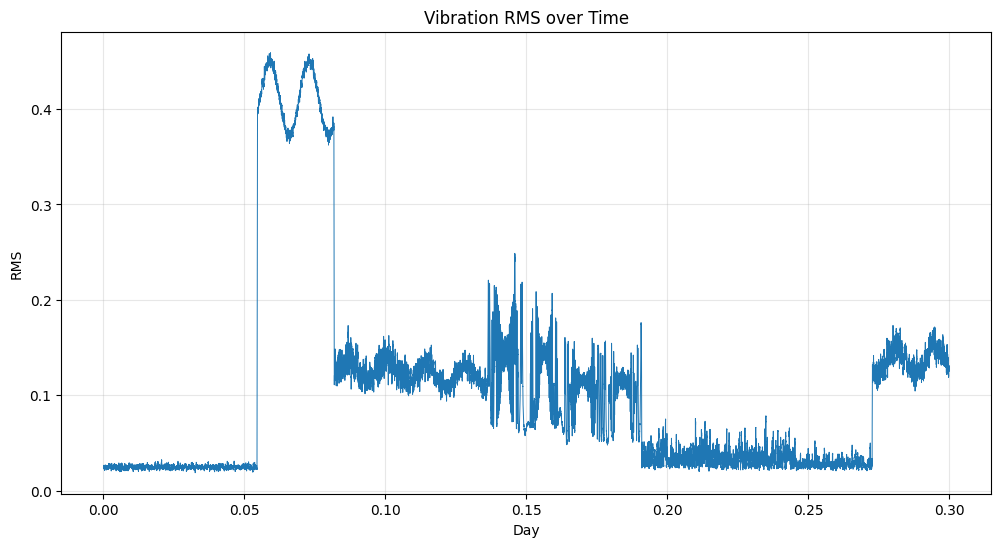

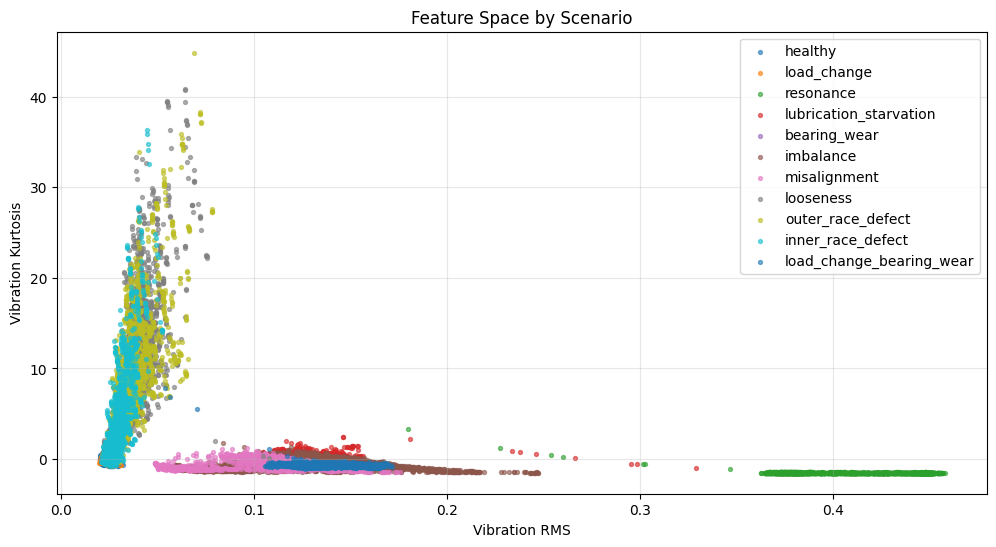

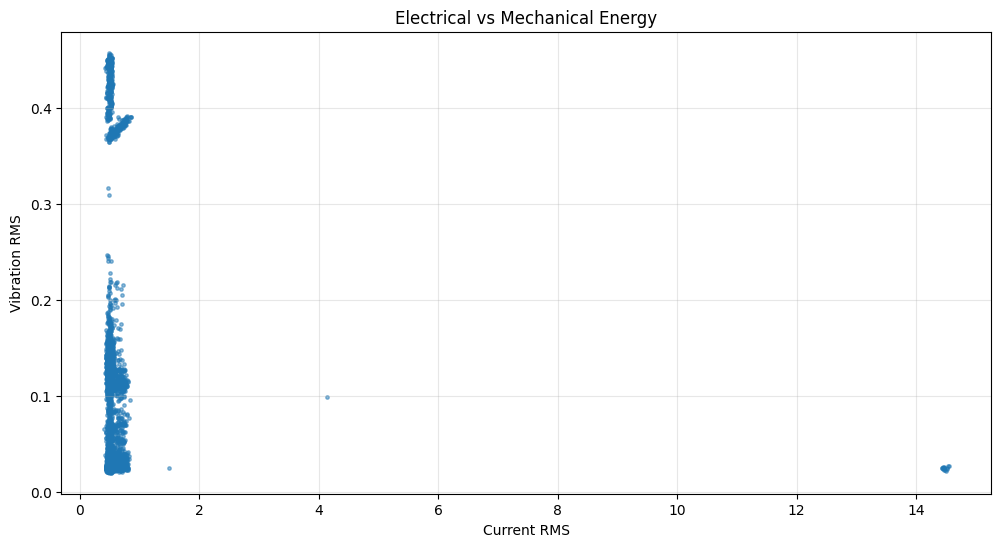

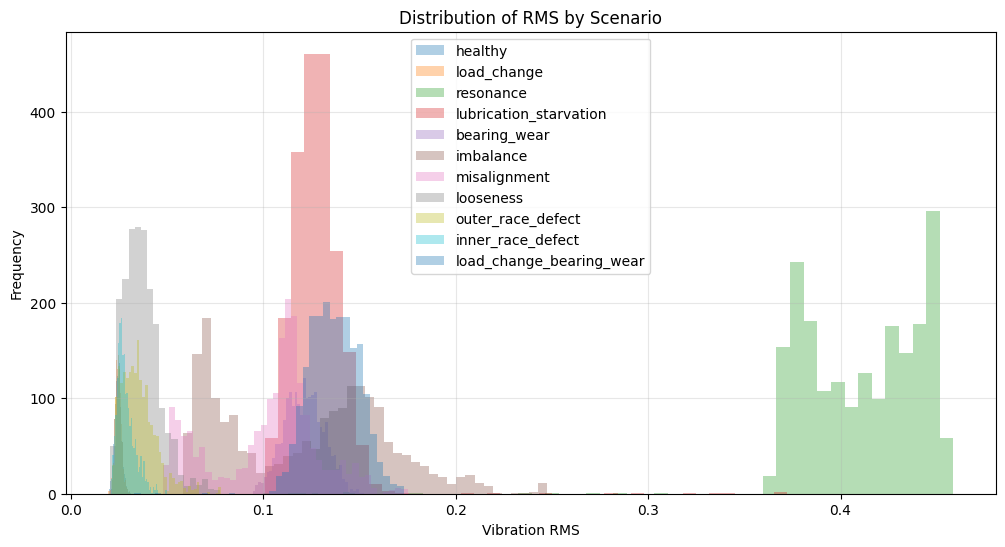

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# RESUMO POR CENÁRIO
# =========================

summary = df.groupby("scenario")[["vibration_rms","vibration_kurtosis"]].mean()

print("\nResumo médio por cenário:")
display(summary.sort_values("vibration_rms", ascending=False))

# =========================
# RMS AO LONGO DO TEMPO
# =========================

plt.figure(figsize=(12,6))

sample = df.sample(min(len(df), 200000)).sort_values("day")

plt.plot(sample['day'], sample['vibration_rms'], linewidth=0.7)

plt.title("Vibration RMS over Time")
plt.xlabel("Day")
plt.ylabel("RMS")
plt.grid(alpha=0.3)

plt.show()


# =========================
# FEATURE SPACE
# =========================

plt.figure(figsize=(12,6))

scenarios = df['scenario'].unique()

for scenario in scenarios:

    subset = df[df['scenario']==scenario]

    sample = subset.sample(min(2000, len(subset)))

    plt.scatter(
        sample['vibration_rms'],
        sample['vibration_kurtosis'],
        s=8,
        alpha=0.6,
        label=scenario
    )

plt.xlabel("Vibration RMS")
plt.ylabel("Vibration Kurtosis")
plt.title("Feature Space by Scenario")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# =========================
# CURRENT VS VIBRATION
# =========================

plt.figure(figsize=(12,6))

sample = df.sample(min(5000, len(df)))

plt.scatter(
    sample['current_rms'],
    sample['vibration_rms'],
    s=6,
    alpha=0.5
)

plt.xlabel("Current RMS")
plt.ylabel("Vibration RMS")

plt.title("Electrical vs Mechanical Energy")

plt.grid(alpha=0.3)

plt.show()


# =========================
# DISTRIBUIÇÃO RMS POR CENÁRIO
# =========================

plt.figure(figsize=(12,6))

for scenario in scenarios:

    subset = df[df['scenario']==scenario]

    sample = subset['vibration_rms'].sample(min(2000, len(subset)))

    plt.hist(
        sample,
        bins=40,
        alpha=0.35,
        label=scenario
    )

plt.xlabel("Vibration RMS")
plt.ylabel("Frequency")

plt.title("Distribution of RMS by Scenario")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Windowing & Features Extraction

To analyze the vibration signal in a structured way, the simulated time series is segmented into **overlapping time windows**. Each window represents a short observation interval of the system's operating behavior.

From each window, a set of statistical descriptors is extracted to summarize the vibration characteristics. These features capture complementary aspects of the signal:

- **RMS** – overall vibration energy level  
- **Standard Deviation (STD)** – dispersion of the signal amplitude  
- **Kurtosis** – impulsiveness associated with shocks or impacts  
- **Crest Factor** – relationship between peaks and average vibration level  
- **Skewness** – asymmetry of the signal distribution

This transformation converts the raw vibration time series into a **feature-based representation**, allowing the monitoring problem to be analyzed in a multivariate statistical framework.

The resulting feature trajectories form the basis for the exploratory analysis and the subsequent fault detection methods.

In [117]:
import numpy as np
import pandas as pd

def extract_features(signal):

    mu = np.mean(signal)
    sigma = np.std(signal) + 1e-8

    rms = np.sqrt(np.mean(signal**2))
    std = sigma
    kurt = np.mean((signal - mu)**4) / (sigma**4)
    crest = np.max(np.abs(signal)) / (rms + 1e-8)
    skew = np.mean((signal - mu)**3) / (sigma**3)

    return [rms, std, kurt, crest, skew]


window = 2000
step = 200

features = []
times = []
scenario_window = []

signal = df["vibration"].values
time_values = df["time"].values
scenario_values = df["scenario"].values

for i in range(window, len(signal), step):

    segment = signal[i-window:i]

    f = extract_features(segment)

    features.append(f)

    # cenário dominante da janela
    scenario_window.append(pd.Series(
        scenario_values[i-window:i]
    ).mode()[0])

    times.append(time_values[i])


features_df = pd.DataFrame(
    features,
    columns=["rms", "std", "kurtosis", "crest", "skew"]
)

features_df["time"] = times
features_df["scenario"] = scenario_window


print(f"Total de janelas: {len(features_df)}")

print("\nOverview do dataset de features:")
print(features_df.describe())
features_df.groupby("scenario")[["rms","kurtosis","crest"]].mean()

Total de janelas: 2581

Overview do dataset de features:
               rms          std     kurtosis        crest         skew  \
count  2581.000000  2581.000000  2581.000000  2581.000000  2581.000000   
mean      0.171746     0.107844     6.395609     2.581074    -0.067435   
std       0.086455     0.106498     7.654091     0.668834     0.155510   
min       0.092682     0.023639     1.507083     1.419508    -0.750032   
25%       0.122627     0.030457     2.364068     1.834116    -0.075238   
50%       0.147552     0.100549     2.959423     2.644569    -0.012693   
75%       0.180058     0.131283     6.527338     2.999633     0.015642   
max       0.468022     0.449289    45.080721     5.244300     0.450497   

                time  
count    2581.000000  
mean   260199.000000  
std    149042.969196  
min      2199.000000  
25%    131199.000000  
50%    260199.000000  
75%    389199.000000  
max    518199.000000  


,rms,kurtosis,crest
scenario,,,
bearing_wear,0.164662,2.334987,2.648793
healthy,0.113627,2.978988,1.726781
imbalance,0.169253,2.775896,2.764781
inner_race_defect,0.115511,9.651202,2.724076
load_change,0.146002,3.116722,1.625037
load_change_bearing_wear,0.197276,2.350706,2.544780
looseness,0.118330,20.105503,3.341858
lubrication_starvation,0.171016,3.034302,3.265507
misalignment,0.152449,2.953403,2.701941


# Exploratory Data Analysis (EDA) over Features

Before designing the detection framework, an exploratory analysis was conducted to understand the statistical relationships between the extracted vibration features.

## Correlations Matrix

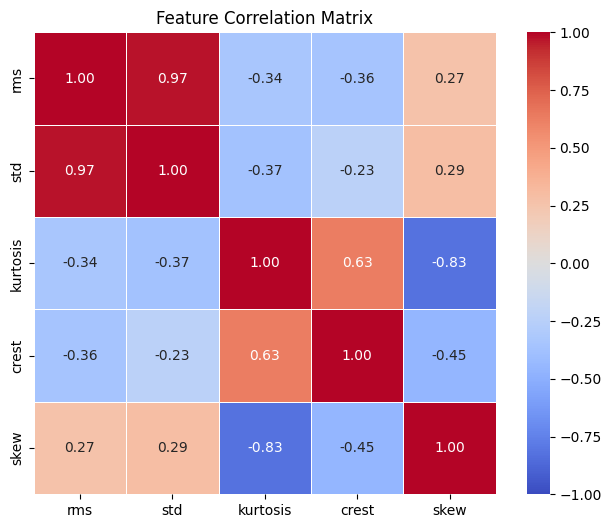

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

# selecionar apenas features numéricas
feature_cols = ["rms", "std", "kurtosis", "crest", "skew"]

corr = features_df[feature_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")

plt.show()

### Feature Selection

The feature correlation matrix reveals a **very strong linear relationship between RMS and STD (ρ ≈ 0.97)**.

Since both metrics capture essentially the same information about the signal amplitude, including both features would introduce **redundancy in the feature space** and negatively affect the conditioning of the covariance matrix used in multivariate detectors.

To avoid multicollinearity and improve numerical stability, the **standard deviation (STD) feature was removed** from the monitoring pipeline.

The final feature set used by the detectors therefore consists of:

- **RMS** – vibration energy indicator  
- **Kurtosis** – impulsiveness indicator  
- **Crest Factor** – peak-to-RMS relationship  
- **Skewness** – signal asymmetry indicator

This reduced feature set preserves complementary statistical information while maintaining a well-conditioned multivariate space for the Mahalanobis-based regime score and subsequent Bayesian inference in BAFO.

## Features Distribution

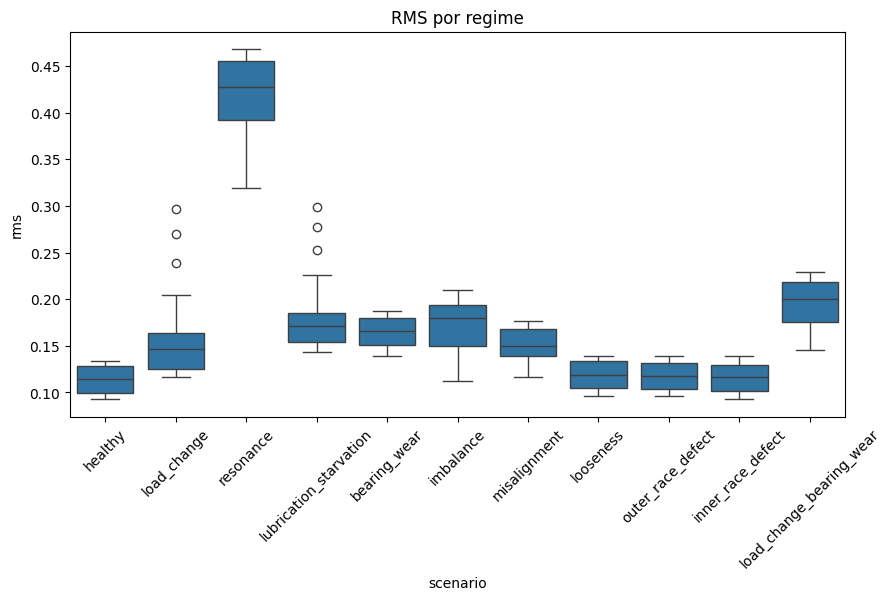

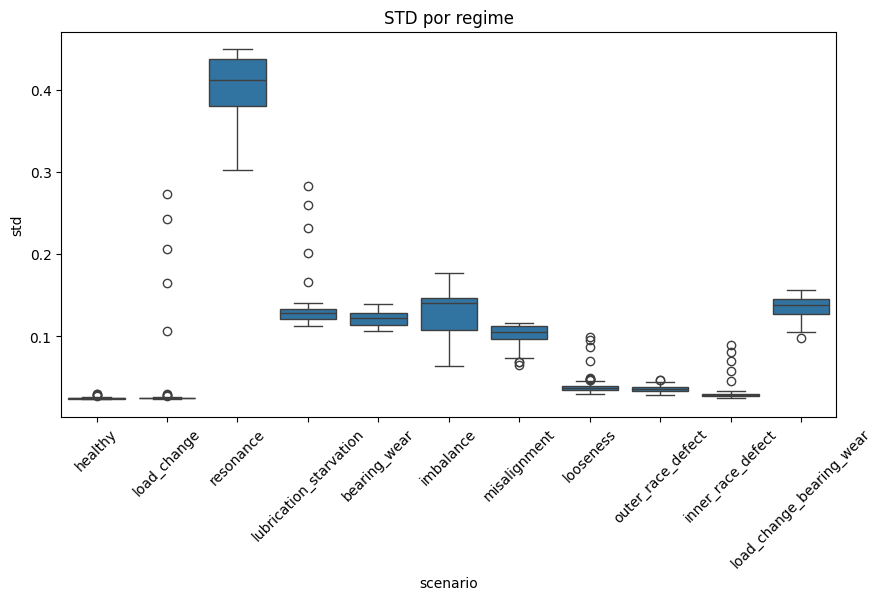

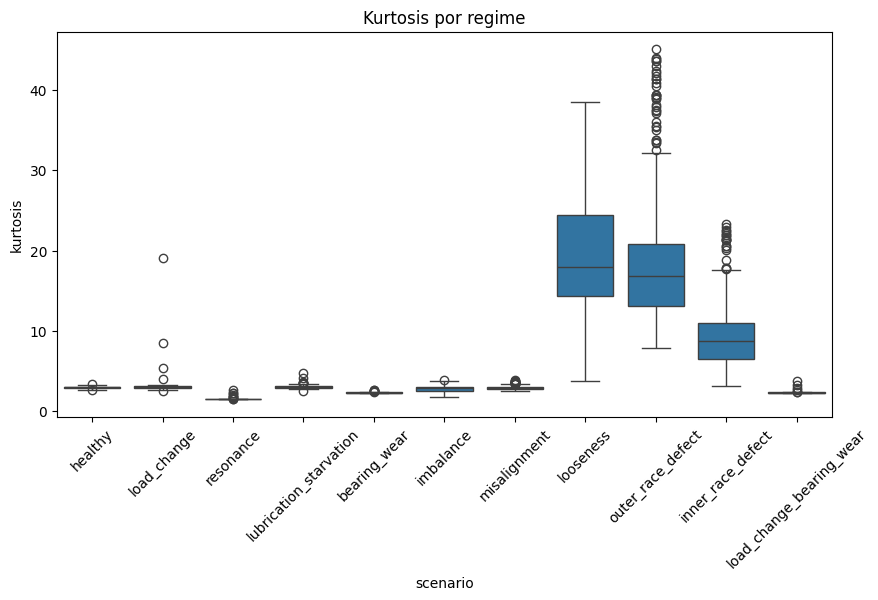

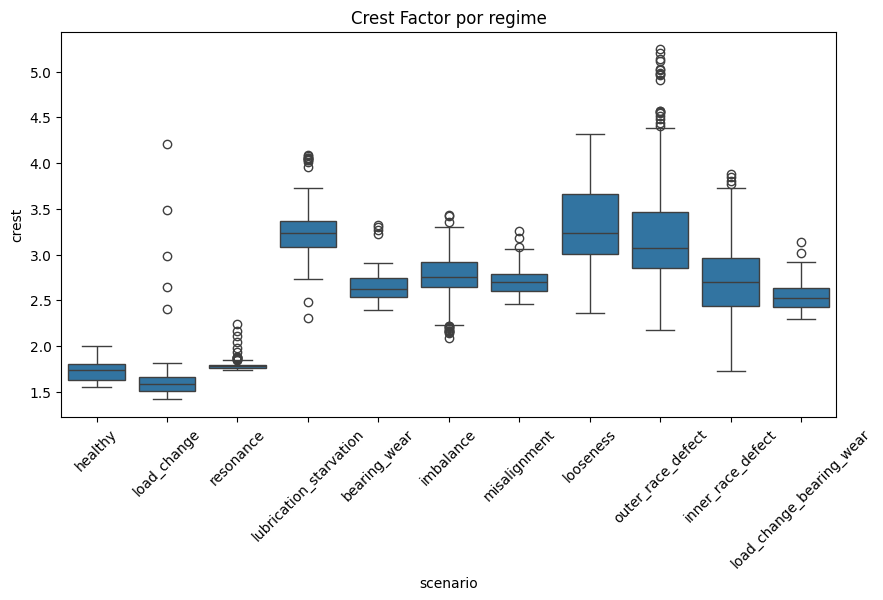

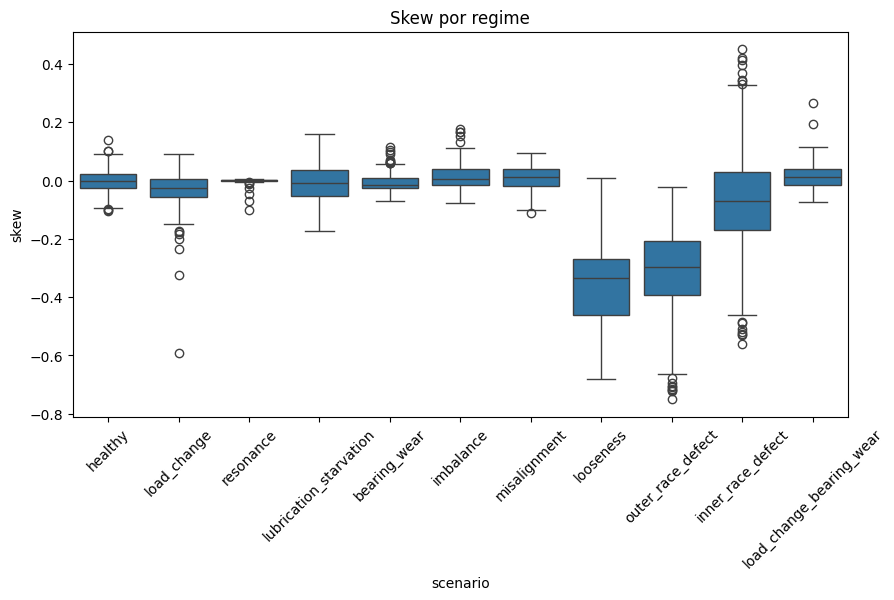

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# RMS
plt.figure(figsize=(10,5))
sns.boxplot(data=features_df, x="scenario", y="rms")
plt.xticks(rotation=45)
plt.title("RMS por regime")
plt.show()

# STD
plt.figure(figsize=(10,5))
sns.boxplot(data=features_df, x="scenario", y="std")
plt.xticks(rotation=45)
plt.title("STD por regime")
plt.show()

# Kurtosis
plt.figure(figsize=(10,5))
sns.boxplot(data=features_df, x="scenario", y="kurtosis")
plt.xticks(rotation=45)
plt.title("Kurtosis por regime")
plt.show()

# Crest
plt.figure(figsize=(10,5))
sns.boxplot(data=features_df, x="scenario", y="crest")
plt.xticks(rotation=45)
plt.title("Crest Factor por regime")
plt.show()

# Skew
plt.figure(figsize=(10,5))
sns.boxplot(data=features_df, x="scenario", y="skew")
plt.xticks(rotation=45)
plt.title("Skew por regime")
plt.show()

### Feature Distribution Across Operational Regimes

The boxplots above illustrate how the statistical vibration features vary across the simulated operational regimes.

As expected, different fault conditions produce distinct changes in the distribution of the extracted features. Faults associated with impacts or structural irregularities tend to increase higher-order statistics such as **kurtosis** and **crest factor**, while changes in operational load are more strongly reflected in **RMS amplitude variations**.

Although the dataset is generated through simulation, the resulting statistical behavior reproduces the characteristic patterns typically observed in vibration-based condition monitoring. This provides a controlled environment in which different fault scenarios produce measurable changes in the feature space.

Such behavior is sufficient for evaluating the response of the proposed detection methods and benchmarking their ability to identify **regime transitions and abnormal operating conditions**.

## Feature Trajectory

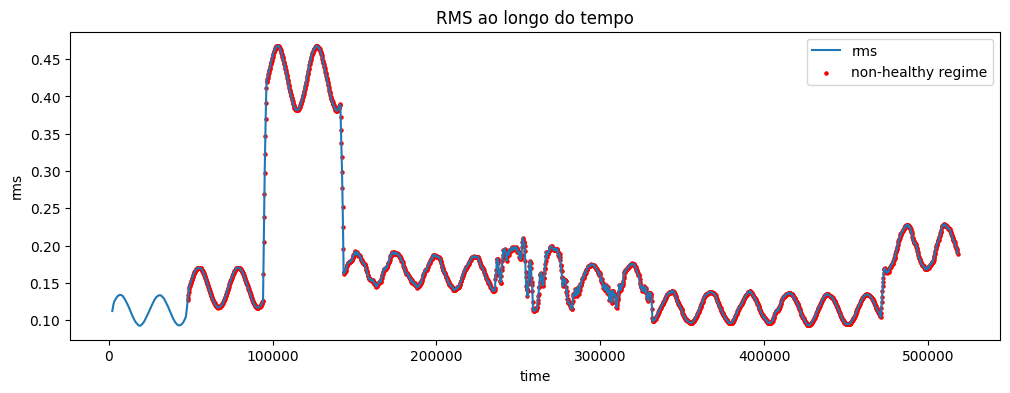

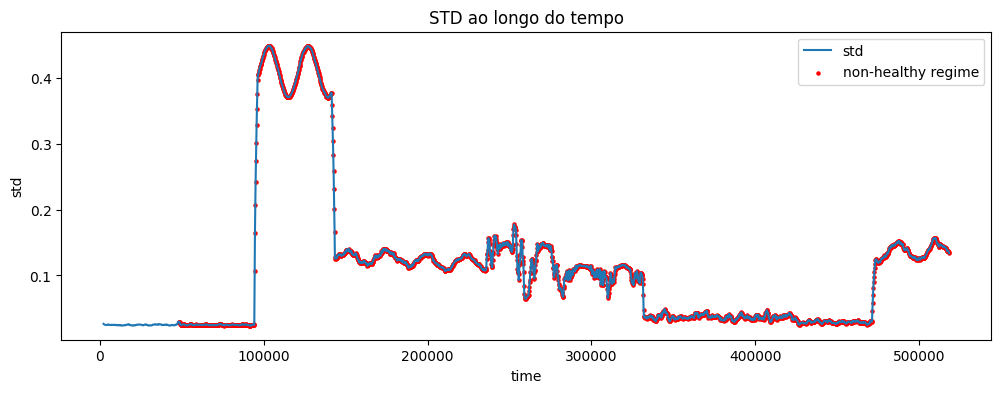

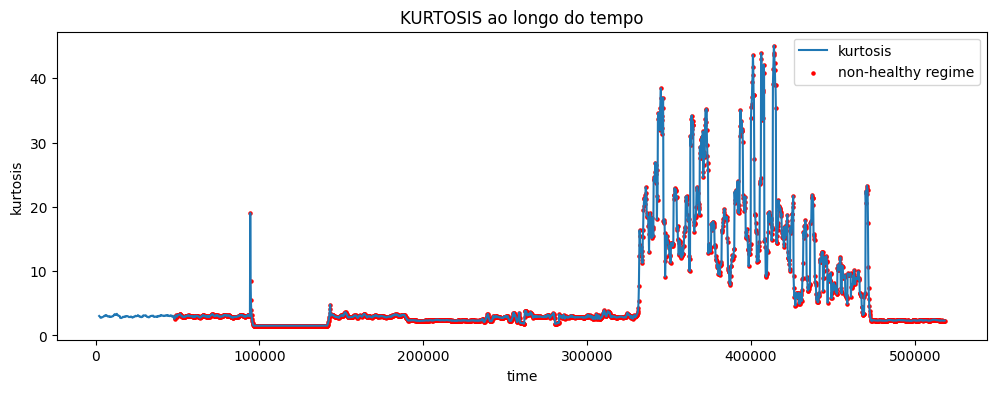

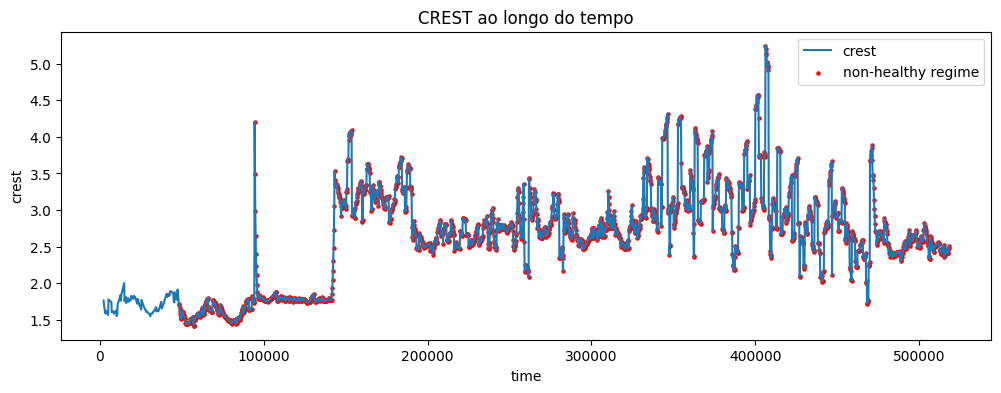

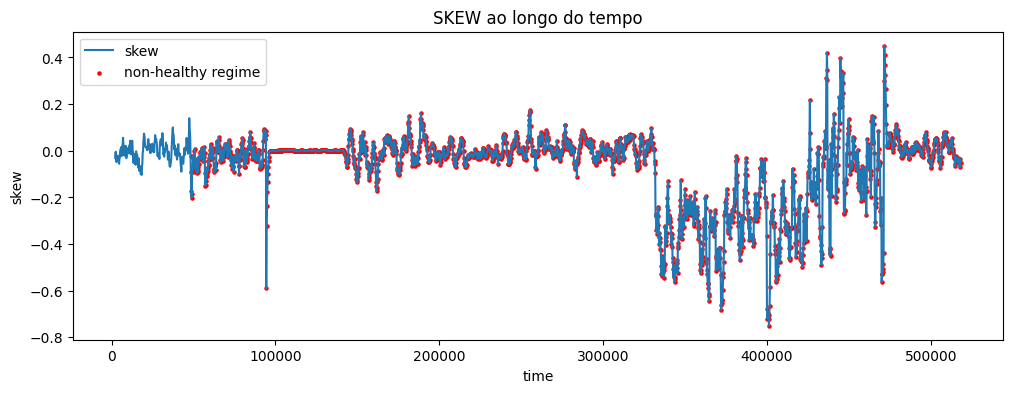

In [123]:
import matplotlib.pyplot as plt

features = ["rms", "std", "kurtosis", "crest", "skew"]

fault_mask = features_df["scenario"] != "healthy"

for f in features:

    plt.figure(figsize=(12,4))

    plt.plot(features_df["time"], features_df[f], label=f)

    plt.scatter(
        features_df["time"][fault_mask],
        features_df[f][fault_mask],
        color="red",
        s=5,
        label="non-healthy regime"
    )

    plt.title(f"{f.upper()} ao longo do tempo")
    plt.xlabel("time")
    plt.ylabel(f)
    plt.legend()

    plt.show()

### Feature Trajectory Across Operational Regimes

The temporal trajectories of the extracted vibration features provide additional insight into how the system behavior evolves across different operating regimes.

As the simulated scenarios progress, the statistical descriptors of the vibration signal exhibit noticeable shifts in magnitude and variability. These transitions reflect the programmed changes in operating conditions and fault mechanisms introduced in the simulation.

The resulting feature trajectories highlight two important aspects for the monitoring problem:

- **regime transitions**, where statistical properties of the signal change abruptly or gradually;
- **persistent deviations**, where the signal maintains a different statistical profile under a fault condition.

These dynamics motivate the use of monitoring methods capable of capturing **both multivariate structure and temporal evolution**, which are explored in the following fault detection framework.

# Fault Detection

Having characterized the statistical behavior of the vibration features, we now introduce the monitoring framework used to detect regime changes and abnormal operating conditions.

## Bayesian Adaptive Fault Observer (BAFO)

### BAFO — Bayesian Adaptive Fault Observer

The core monitoring method proposed in this work is the **Bayesian Adaptive Fault Observer (BAFO)**.

BAFO is designed as a probabilistic state observer that integrates multivariate statistical evidence with temporal dynamics in order to track the health state of the monitored system.

The method operates in three conceptual stages:

1. **Evidence generation** from the multivariate regime signal.
2. **Bayesian integration**, which updates the probability of abnormal behavior.
3. **Health state estimation**, which acts as a smoothed observer of system degradation.

This structure allows BAFO to react to regime changes while maintaining robustness to impulsive noise and transient disturbances in the vibration signal.

In [171]:
import numpy as np
import pandas as pd
from scipy.stats import norm


def Bayesian_Adaptive_State_Observer(
    signal,
    normal_signal,
    prior_fault=0.01,
    lambda_slope=1.6, #2.5,
    tau=50,
    forgetting=0.995,
    threshold=0.75
):

    signal = np.asarray(signal)
    normal_signal = np.asarray(normal_signal)

    # smoothing
    signal_smooth = pd.Series(signal).rolling(
        window=5,
        min_periods=1
    ).mean().values

    # baseline statistics
    mu_norm = np.mean(normal_signal)
    sigma_norm = np.std(normal_signal) + 1e-8

    slope = np.gradient(signal_smooth)
    
    slope = pd.Series(slope).rolling(
        window=5,
        min_periods=1
    ).mean().values
    
    slope = np.clip(slope, -3, 3)

    # regime signal
    x_signal = (
        (signal_smooth - mu_norm) / sigma_norm
        + lambda_slope * slope
    )

    Ts = 1
    alpha = np.exp(-Ts / tau)

    posterior = prior_fault

    posterior_series = []
    deg_series = []

    deg_est = 0

    for x in x_signal:

        posterior_memory = forgetting * posterior
        posterior_pred = alpha * posterior_memory + (1 - alpha) * prior_fault

        # adaptive baseline update
        if posterior < 0.1: #0.2

            mu_norm = forgetting * mu_norm + (1 - forgetting) * x

            sigma_norm = np.sqrt(
                forgetting * sigma_norm**2
                + (1 - forgetting) * (x - mu_norm)**2
            )

        z = (x - mu_norm) / (sigma_norm + 1e-8)
        # Smoothing
        z = np.tanh(z / 3) * 3
        
        p_norm = norm.pdf(z, 0, 1)
        p_fault = norm.pdf(abs(z), loc=3.0, scale=1.5)

        den = (p_fault * posterior_pred) + (p_norm * (1 - posterior_pred))

        posterior_bayes = (p_fault * posterior_pred) / (den + 1e-12)

        # saturation protection
        if posterior > 0.95 and posterior_bayes > posterior_pred:
            posterior_bayes = posterior_pred

        gamma = 0.05 + 0.15 * abs(z) / (2 + abs(z))

        posterior_update = posterior_pred + gamma * (posterior_bayes - posterior_pred)
        # Smoothing
        posterior = 0.9 * posterior_update + 0.1 * posterior_bayes

        posterior = np.clip(posterior, 1e-6, 1 - 1e-6)

        # health state
        beta = 0.995
        deg_est = beta * deg_est + (1 - beta) * posterior

        posterior_series.append(posterior)
        deg_series.append(deg_est)

    posterior_series = np.array(posterior_series)
    deg_series = np.array(deg_series)

    detection_index = next(
        (i for i, p in enumerate(posterior_series) if p >= threshold),
        None
    )

    return {
        "posterior": posterior_series,
        "deg_est": deg_series,
        "detected_index": detection_index
    }

## Benchmark vs Treshold, PCA + Hotelling T² (MSPC)

### Benchmark Detectors

To provide a meaningful comparison, the BAFO observer is evaluated against two widely used monitoring approaches:

- **RMS threshold monitoring**, representing a simple amplitude-based detector commonly used in industrial vibration monitoring.
- **PCA-based Multivariate Statistical Process Control (MSPC)** using the Hotelling T² statistic, a classical multivariate anomaly detection method.

These benchmarks provide reference baselines for evaluating the detection capability and temporal behavior of the proposed observer.

In [174]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# ------------------------------------------------
# Baseline
# ------------------------------------------------

normal_scenarios = ["healthy", "load_change"]

normal_df = features_df[
    features_df["scenario"].isin(normal_scenarios)
]

normal_signal = normal_df["rms"].values

threshold_trad = np.mean(normal_signal) + 3.5 * np.std(normal_signal)

# ------------------------------------------------
# Multivariate signal
# ------------------------------------------------

features = ["rms", "kurtosis", "crest", "skew"]

mu = normal_df[features].mean()

# Tikhonov regularization
cov = normal_df[features].cov()
cov += np.eye(len(features)) * 1e-4
inv_cov = np.linalg.inv(cov)

# Impact Detector
def mahalanobis(row):
    d = row - mu
    return np.sqrt(d @ inv_cov @ d)

maha_raw = features_df[features].apply(mahalanobis, axis=1)

# Filtering into energy regime
x_signal = pd.Series(maha_raw).rolling(
    window=30,
    min_periods=1
).mean()

normal_s = x_signal[
    features_df["scenario"].isin(normal_scenarios)
].values

# ------------------------------------------------
# PCA Benchmark (MSPC)
# ------------------------------------------------

pca = PCA(n_components=2)

X_train = normal_df[features].values
pca_scores = pca.fit_transform(X_train)

lambda_vals = pca.explained_variance_

def hotelling_T2(x):

    score = pca.transform(x.reshape(1,-1))[0]

    T2 = np.sum((score**2) / lambda_vals)

    return T2


T2_series = []

for _, row in features_df[features].iterrows():

    T2 = hotelling_T2(row.values)

    T2_series.append(T2)

T2_series = np.array(T2_series)

# Threshold for PCA detector

T2_baseline = T2_series[
    features_df["scenario"].isin(normal_scenarios)
]

T2_threshold = np.mean(T2_baseline) + 3 * np.std(T2_baseline)

# ------------------------------------------------
# Detection comparison
# ------------------------------------------------

results = []

for scenario in features_df["scenario"].unique():

    mask = features_df["scenario"] == scenario
    indices = np.where(mask)[0]

    start_idx = indices[0]

    # -------------------------
    # Threshold detector
    # -------------------------

    signal_thr = signal[mask]

    idx_thr = np.where(signal_thr > threshold_trad)[0]
    idx_thr = idx_thr[0] if len(idx_thr) > 0 else None

    # -------------------------
    # PCA detector
    # -------------------------

    signal_pca = T2_series[mask]

    idx_pca = np.where(signal_pca > T2_threshold)[0]
    idx_pca = idx_pca[0] if len(idx_pca) > 0 else None

    # -------------------------
    # BAFO detector
    # -------------------------

    signal_bayes = x_signal[mask].values

    res = Bayesian_Adaptive_State_Observer(signal_bayes, normal_s)

    idx_bayes = res["detected_index"]

    # -------------------------
    # global indices
    # -------------------------

    idx_thr_global = start_idx + idx_thr if idx_thr is not None else None
    idx_pca_global = start_idx + idx_pca if idx_pca is not None else None
    idx_bayes_global = start_idx + idx_bayes if idx_bayes is not None else None

    results.append({
        "scenario": scenario,
        "threshold_idx": idx_thr_global,
        "pca_idx": idx_pca_global,
        "bayes_idx": idx_bayes_global
    })

results_df = pd.DataFrame(results)

# ------------------------------------------------
# Time conversion
# ------------------------------------------------

time_step = step * sim.dt

results_df["threshold_time"] = results_df["threshold_idx"] * time_step
results_df["pca_time"] = results_df["pca_idx"] * time_step
results_df["bayes_time"] = results_df["bayes_idx"] * time_step

results_df = results_df.sort_values("bayes_time")

print(results_df)

                    scenario  threshold_idx  pca_idx  bayes_idx  \
0                    healthy            NaN      NaN          7   
1                load_change          463.0    461.0        316   
2                  resonance          466.0      NaN        473   
3     lubrication_starvation          701.0    704.0        708   
4               bearing_wear            NaN    937.0        944   
5                  imbalance            NaN   1179.0       1180   
6               misalignment            NaN   1412.0       1415   
7                  looseness            NaN   1644.0       1651   
8          outer_race_defect            NaN   1880.0       1887   
9          inner_race_defect            NaN   2115.0       2122   
10  load_change_bearing_wear         2413.0   2351.0       2358   

    threshold_time  pca_time  bayes_time  
0              NaN       NaN        70.0  
1           4630.0    4610.0      3160.0  
2           4660.0       NaN      4730.0  
3           7010.0    7

## Visualization

### Monitoring Visualization


To facilitate interpretation of the monitoring results, a consolidated visualization dashboard is constructed.

The dashboard combines multiple perspectives of the monitoring problem, including:

- the operational regime timeline
- the multivariate regime score
- classical threshold monitoring
- the BAFO probabilistic state estimates

This visualization allows a direct comparison between the proposed observer and the benchmark detectors across all simulated operating conditions.

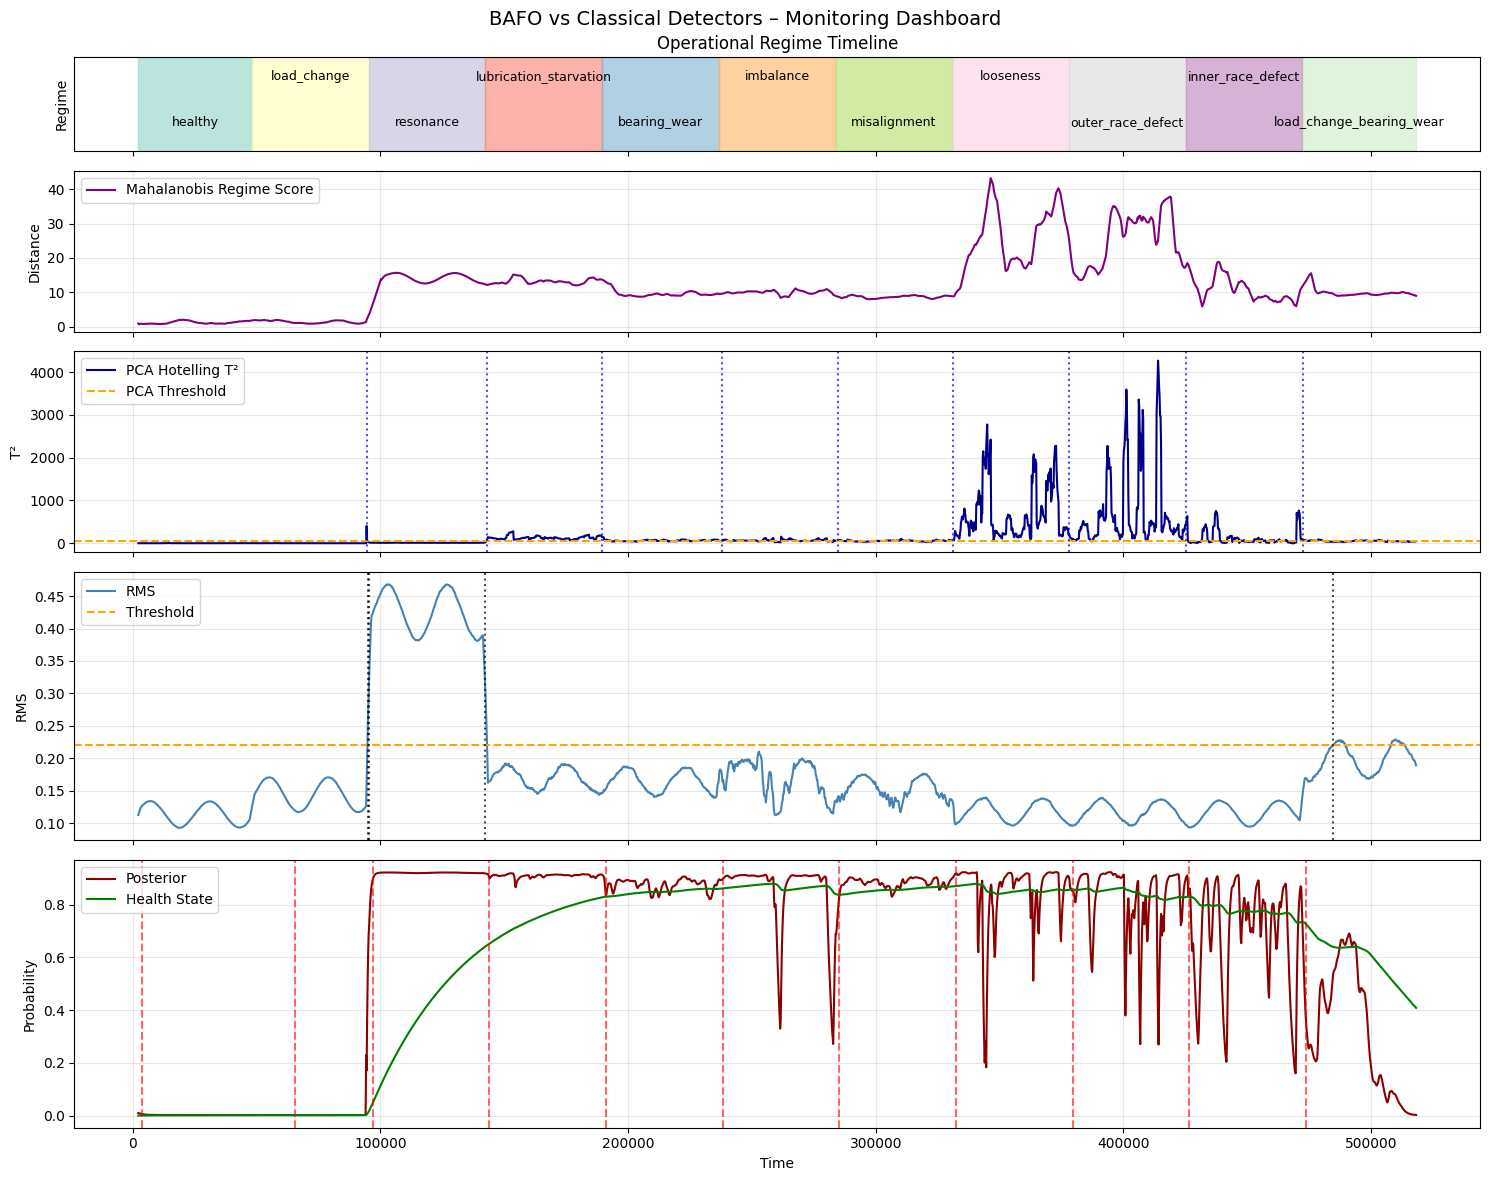

In [183]:
import matplotlib.pyplot as plt
import numpy as np

signal = features_df["rms"].values
time = features_df["time"].values
scenario = features_df["scenario"].values

scale = np.max(signal)

fig, axes = plt.subplots(
    5, 1,
    figsize=(15,12),
    sharex=True,
    gridspec_kw={"height_ratios":[0.7,1.2,1.5,2,2]}
)

ax_regime, ax_maha, ax_pca, ax_signal, ax_bayes = axes


# ==============================
# REGIME TIMELINE
# ==============================

unique_scenarios = features_df["scenario"].unique()
colors = plt.cm.Set3.colors

for i, sc in enumerate(unique_scenarios):

    mask = features_df["scenario"] == sc

    start = features_df[mask]["time"].iloc[0]
    end = features_df[mask]["time"].iloc[-1]

    ax_regime.axvspan(
        start,
        end,
        color=colors[i % len(colors)],
        alpha=0.6
    )

    y_text = 0.30 if i % 2 == 0 else 0.80

    ax_regime.text(
        (start + end) / 2,
        y_text,
        sc,
        ha="center",
        va="center",
        fontsize=9
    )

ax_regime.set_yticks([])
ax_regime.set_ylabel("Regime")
ax_regime.set_title("Operational Regime Timeline")


# ==============================
# MAHALANOBIS SCORE
# ==============================

ax_maha.plot(
    time,
    x_signal,
    color="purple",
    label="Mahalanobis Regime Score"
)

ax_maha.set_ylabel("Distance")
ax_maha.legend(loc="upper left")
ax_maha.grid(alpha=0.3)


# ==============================
# PCA HOTELLING T²
# ==============================

ax_pca.plot(
    time,
    T2_series,
    color="darkblue",
    label="PCA Hotelling T²"
)

ax_pca.axhline(
    T2_threshold,
    linestyle="--",
    color="orange",
    label="PCA Threshold"
)

for idx in results_df["pca_idx"].dropna():

    ax_pca.axvline(
        time[int(idx)],
        color="blue",
        linestyle=":",
        alpha=0.7
    )

ax_pca.set_ylabel("T²")
ax_pca.legend(loc="upper left")
ax_pca.grid(alpha=0.3)


# ==============================
# RMS SIGNAL
# ==============================

ax_signal.plot(
    time,
    signal,
    color="steelblue",
    label="RMS"
)

ax_signal.axhline(
    threshold_trad,
    linestyle="--",
    color="orange",
    label="Threshold"
)

for idx in results_df["threshold_idx"].dropna():

    ax_signal.axvline(
        time[int(idx)],
        color="black",
        linestyle=":",
        alpha=0.7
    )

ax_signal.set_ylabel("RMS")
ax_signal.legend(loc="upper left")
ax_signal.grid(alpha=0.3)


# ==============================
# BAFO OBSERVER
# ==============================

ax_bayes.plot(
    time,
    posterior,
    color="darkred",
    label="Posterior"
)

ax_bayes.plot(
    time,
    deg_est,
    color="green",
    label="Health State"
)

for idx in results_df["bayes_idx"].dropna():

    ax_bayes.axvline(
        time[int(idx)],
        color="red",
        linestyle="--",
        alpha=0.6
    )

ax_bayes.set_ylabel("Probability")
ax_bayes.set_xlabel("Time")

ax_bayes.legend(loc="upper left")
ax_bayes.grid(alpha=0.3)


plt.suptitle(
    "BAFO vs Classical Detectors – Monitoring Dashboard",
    fontsize=14
)

plt.tight_layout()

plt.show()

## Phase Portrait

### BAFO Phase Portrait


To further analyze the behavior of the probabilistic observer, a phase portrait is constructed using the BAFO **posterior probability** and the estimated **health state**.

This representation highlights the dynamic relationship between instantaneous anomaly evidence and the smoothed degradation estimate produced by the observer.

The resulting trajectories provide insight into how the BAFO framework transitions between healthy operation, regime shifts, and persistent fault conditions.

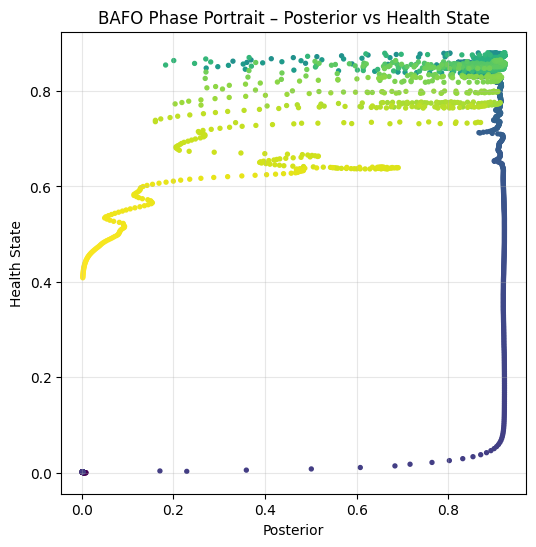

In [185]:
plt.figure(figsize=(6,6))

plt.scatter(
    posterior,
    deg_est,
    c=np.arange(len(posterior)),
    cmap="viridis",
    s=8
)

plt.xlabel("Posterior")
plt.ylabel("Health State")

plt.title("BAFO Phase Portrait – Posterior vs Health State")

plt.grid(alpha=0.3)

plt.show()

# Conclusions and Results

## Regime Space Map

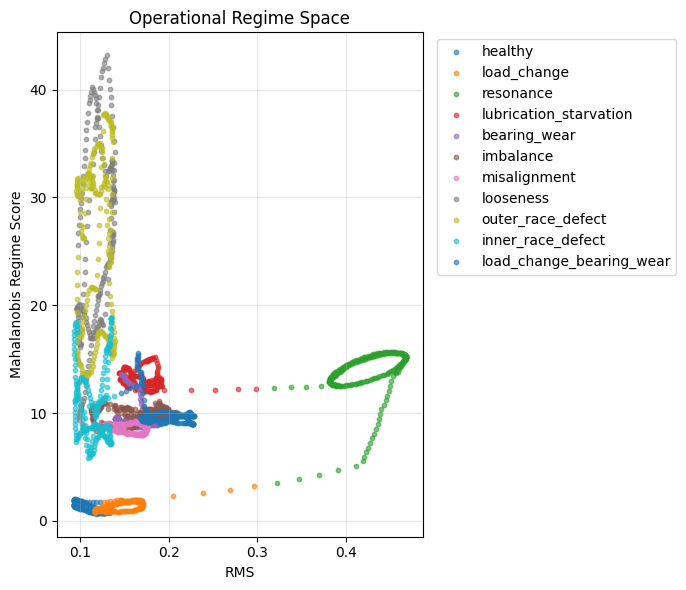

In [180]:
plt.figure(figsize=(7,6))

unique_scenarios = features_df["scenario"].unique()
colors = plt.cm.tab10.colors

for i, sc in enumerate(unique_scenarios):

    mask = features_df["scenario"] == sc

    plt.scatter(
        signal[mask],
        x_signal[mask],
        s=10,
        alpha=0.6,
        color=colors[i % len(colors)],
        label=sc
    )

plt.xlabel("RMS")
plt.ylabel("Mahalanobis Regime Score")

plt.title("Operational Regime Space")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Detection Delay

### Calculations

In [176]:
# ------------------------------------------------
# Detection delay
# ------------------------------------------------

delays = []

for scenario in results_df["scenario"]:

    mask = features_df["scenario"] == scenario
    start_idx = np.where(mask)[0][0]

    thr = results_df.loc[
        results_df["scenario"] == scenario, "threshold_idx"
    ].values[0]

    pca = results_df.loc[
        results_df["scenario"] == scenario, "pca_idx"
    ].values[0]

    bayes = results_df.loc[
        results_df["scenario"] == scenario, "bayes_idx"
    ].values[0]

    thr_delay = thr - start_idx if pd.notna(thr) else np.nan
    pca_delay = pca - start_idx if pd.notna(pca) else np.nan
    bayes_delay = bayes - start_idx if pd.notna(bayes) else np.nan

    delays.append({
        "scenario": scenario,
        "threshold_delay": thr_delay,
        "pca_delay": pca_delay,
        "bayes_delay": bayes_delay
    })

delay_df = pd.DataFrame(delays)

print(delay_df)

                    scenario  threshold_delay  pca_delay  bayes_delay
0                    healthy              NaN        NaN            7
1                load_change            233.0      231.0           86
2                  resonance              0.0        NaN            7
3     lubrication_starvation              0.0        3.0            7
4               bearing_wear              NaN        0.0            7
5                  imbalance              NaN        6.0            7
6               misalignment              NaN        4.0            7
7                  looseness              NaN        0.0            7
8          outer_race_defect              NaN        0.0            7
9          inner_race_defect              NaN        0.0            7
10  load_change_bearing_wear             62.0        0.0            7


### Visualization

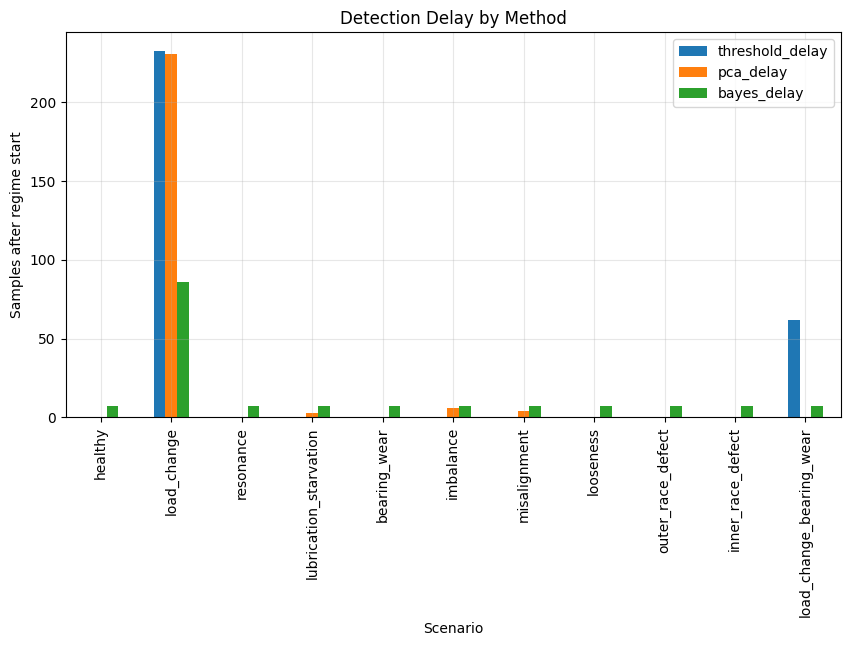

In [177]:
delay_df_plot = delay_df.set_index("scenario")

delay_df_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Detection Delay by Method")
plt.ylabel("Samples after regime start")
plt.xlabel("Scenario")

plt.grid(alpha=0.3)

plt.show()

## Fault Detection Map

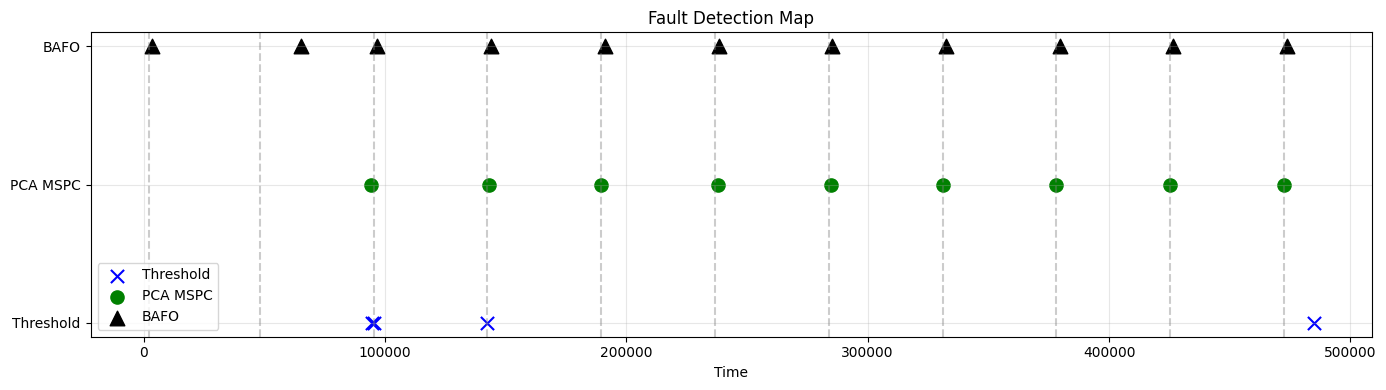

In [181]:
plt.figure(figsize=(14,4))

# ---------------------------
# regime transitions
# ---------------------------

unique_scenarios = features_df["scenario"].unique()

for i, sc in enumerate(unique_scenarios):

    mask = features_df["scenario"] == sc

    start = features_df[mask]["time"].iloc[0]

    plt.axvline(
        start,
        color="gray",
        linestyle="--",
        alpha=0.4
    )

# ---------------------------
# Threshold detections
# ---------------------------

for i, idx in enumerate(results_df["threshold_idx"].dropna()):

    plt.scatter(
        time[int(idx)],
        1,
        marker="x",
        s=90,
        color="blue",
        label="Threshold" if i == 0 else ""
    )

# ---------------------------
# PCA detections
# ---------------------------

for i, idx in enumerate(results_df["pca_idx"].dropna()):

    plt.scatter(
        time[int(idx)],
        2,
        marker="o",
        s=90,
        color="green",
        label="PCA MSPC" if i == 0 else ""
    )

# ---------------------------
# BAFO detections
# ---------------------------

for i, idx in enumerate(results_df["bayes_idx"].dropna()):

    plt.scatter(
        time[int(idx)],
        3,
        marker="^",
        s=110,
        color="black",
        label="BAFO" if i == 0 else ""
    )

plt.yticks(
    [1,2,3],
    ["Threshold","PCA MSPC","BAFO"]
)

plt.xlabel("Time")

plt.title("Fault Detection Map")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Final Remarks

The **Bayesian Adaptive Fault Observer (BAFO)** demonstrated consistent and reliable detection across all simulated operational regimes.

In contrast, classical **RMS threshold monitoring** failed to identify several structural faults, particularly those that do not produce significant amplitude variations in the vibration signal.

When compared to **PCA-based Multivariate Statistical Process Control (MSPC)**, BAFO showed comparable detection capability while providing smoother temporal behavior and improved stability.

This behavior emerges from the **probabilistic state observer formulation**, which integrates:

- multivariate statistical evidence
- temporal dynamics
- Bayesian inference

As a result, BAFO operates as a **dynamic regime divergence detector**, capable of identifying changes in operational behavior while maintaining robustness to impulsive noise and transient disturbances.

These results suggest that probabilistic observers inspired by control theory can provide an effective alternative to classical static monitoring approaches in industrial condition monitoring systems.